In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/feature_engineering_data.csv")
df

,year,month,retail_sales,retail_transfers,warehouse_sales,total_movement,item_type_DUNNAGE,item_type_KEGS,item_type_LIQUOR,item_type_NON-ALCOHOL,item_type_REF,item_type_STR_SUPPLIES,item_type_WINE,supplier_freq
0,2026,6,0.0,0.0,2.0,2.0,False,False,False,False,False,False,True,6
1,2026,6,0.0,0.0,1.0,1.0,False,False,False,False,False,False,True,6
2,2026,6,0.0,0.0,4.0,4.0,False,False,False,False,False,False,True,6
3,2026,6,0.0,0.0,1.0,1.0,False,False,False,False,False,False,True,6
4,2026,6,0.0,0.0,2.0,2.0,False,False,False,False,False,False,True,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318841,2017,6,0.0,0.0,1.0,1.0,False,False,False,False,False,False,True,44
318842,2017,6,0.0,0.0,1.0,1.0,False,False,False,False,False,False,True,44
318843,2017,6,0.0,0.0,1.0,1.0,False,False,False,False,False,False,True,44
318844,2017,6,0.0,0.0,1.0,1.0,False,False,False,False,False,False,True,44


# Linear Regression
## model A - All feature

In [3]:
# make linear regression
# define target and feature
y = df["retail_sales"]
X = df.drop(columns="retail_sales")

# split data into test and training set
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# define model
lg = LinearRegression()
lg.fit(X_train, y_train)

# check score
print("Training score:",lg.score(X_train, y_train))
print("Test score",lg.score(X_test, y_test))

# check metrics
pred = lg.predict(X_test)

print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred) ** 0.5)
print("R2  :", r2_score(y_test, pred))

r2 = r2_score(y_test, pred)
mae = mean_absolute_error(y_test, pred)
rmse = mae ** 0.5

Training score: 0.9581295323121425
Test score 0.9591504397160842
MAE : 1.7383774853483072
RMSE: 6.458983637239474
R2  : 0.9591504397160842


In [4]:
X.columns

Index(['year', 'month', 'retail_transfers', 'warehouse_sales',
       'total_movement', 'item_type_DUNNAGE', 'item_type_KEGS',
       'item_type_LIQUOR', 'item_type_NON-ALCOHOL', 'item_type_REF',
       'item_type_STR_SUPPLIES', 'item_type_WINE', 'supplier_freq'],
      dtype='str')

## Model B - Without retail_transfers

In [5]:
# make linear regression
# define target and feature
y = df["retail_sales"]
X = df.drop(columns=["retail_sales", "retail_transfers"])

# split data into test and training set
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# define model
lg = LinearRegression()
lg.fit(X_train, y_train)

# check score
print("Training score:",lg.score(X_train, y_train))
print("Test score",lg.score(X_test, y_test))

# check metrics
pred = lg.predict(X_test)

print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred) ** 0.5)
print("R2  :", r2_score(y_test, pred))

r2_no_transfers = r2_score(y_test, pred)
mae_no_transfers = mean_absolute_error(y_test, pred)
rmse_no_transfers = mae_no_transfers ** 0.5

Training score: 0.9581295323121425
Test score 0.9591504397160854
MAE : 1.738377485348
RMSE: 6.458983637239385
R2  : 0.9591504397160854


## Model C - Without retail_transfers & total_movement

In [6]:
# make linear regression
# define target and feature
y = df["retail_sales"]
X = df.drop(columns=["retail_sales", "retail_transfers","total_movement"])

# split data into test and training set
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# define model
lg = LinearRegression()
lg.fit(X_train, y_train)

# check score
print("Training score:",lg.score(X_train, y_train))
print("Test score",lg.score(X_test, y_test))

# check metrics
pred = lg.predict(X_test)

print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred) ** 0.5)
print("R2  :", r2_score(y_test, pred))

r2_no_transfers_movement = r2_score(y_test, pred)
mae_no_transfers_movement = mean_absolute_error(y_test, pred)
rmse_no_transfers_movement = mae_no_transfers_movement ** 0.5

Training score: 0.24652117217574032
Test score 0.3267453565984413
MAE : 8.841570621595757
RMSE: 26.221659284865346
R2  : 0.3267453565984413


# Random Forest Regressor
## Model A - All feature

In [7]:
# make random forest regressor
# define target and feature
y = df["retail_sales"]
X = df.drop(columns=["retail_sales"])

# split data into test and training set
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# define model
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

print("Train:", rf.score(X_train, y_train))
print("Test:", rf.score(X_test, y_test))

# check metrics
pred = rf.predict(X_test)

print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred) ** 0.5)
print("R2  :", r2_score(y_test, pred))

r2_rf = r2_score(y_test, pred)
mae_rf = mean_absolute_error(y_test, pred)
rmse_rf = mae ** 0.5

Train: 0.9929625594378108
Test: 0.9580463131126058
MAE : 1.7193845666149872
RMSE: 6.545691870372925
R2  : 0.9580463131126058


## Model B - Without retail_transfers

In [8]:
# make random forest regressor
# define target and feature
y = df["retail_sales"]
X = df.drop(columns=["retail_sales", "retail_transfers"])

# split data into test and training set
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# define model
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

print("Train:", rf.score(X_train, y_train))
print("Test:", rf.score(X_test, y_test))

# check metrics
pred = rf.predict(X_test)

print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred) ** 0.5)
print("R2  :", r2_score(y_test, pred))

r2_rf_no_transfers = r2_score(y_test, pred)
mae_rf_no_transfers = mean_absolute_error(y_test, pred)
rmse_rf_no_transfers = mae_rf_no_transfers ** 0.5

Train: 0.9843287763954067
Test: 0.8990990841524106
MAE : 1.9560312605974535
RMSE: 10.151215451444743
R2  : 0.8990990841524106


## Model C - Without retail_transfers & warehouse_sales

In [9]:
# make random forest regressor
# define target and feature
y = df["retail_sales"]
X = df.drop(columns=["retail_sales", "retail_transfers","total_movement"])

# split data into test and training set
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# define model
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

print("Train:", rf.score(X_train, y_train))
print("Test:", rf.score(X_test, y_test))

# check metrics
pred = rf.predict(X_test)

print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred) ** 0.5)
print("R2  :", r2_score(y_test, pred))

r2_rf_no_transfers_movement = r2_score(y_test, pred)
mae_rf_no_transfers_movement = mean_absolute_error(y_test, pred)
rmse_rf_no_transfers_movement = mae_rf_no_transfers ** 0.5

Train: 0.8193877388673935
Test: 0.48082516866218183
MAE : 6.108249496238897
RMSE: 23.026466905418424
R2  : 0.48082516866218183


# Comparison Table

In [10]:
results = []

results.append({
    "Model": "Linear Regression",
    "Features": "All Features",
    "R2": r2,
    "MAE": mae,
    "RMSE": rmse
})

results.append({
    "Model": "Linear Regression",
    "Features": "without retail_transfers",
    "R2": r2_no_transfers,
    "MAE": mae_no_transfers,
    "RMSE": rmse_no_transfers
})

results.append({
    "Model": "Linear Regression",
    "Features": "without retail_transfers & total_movement",
    "R2": r2_no_transfers_movement,
    "MAE": mae_no_transfers_movement,
    "RMSE": rmse_no_transfers_movement
})

In [11]:
results.append({
    "Model": "Random Forest Regressor",
    "Features": "All Features",
    "R2": r2_rf,
    "MAE": mae_rf,
    "RMSE": rmse_rf
})

results.append({
    "Model": "Random Forest Regressor",
    "Features": "without retail_transfers",
    "R2": r2_rf_no_transfers,
    "MAE": mae_rf_no_transfers,
    "RMSE": rmse_rf_no_transfers
})

results.append({
    "Model": "Random Forest Regressor",
    "Features": "without retail_transfers & total_movement",
    "R2": r2_rf_no_transfers_movement,
    "MAE": mae_rf_no_transfers_movement,
    "RMSE": rmse_rf_no_transfers_movement
})

In [12]:
comparison = pd.DataFrame(results)
comparison = comparison.round(3)
comparison

,Model,Features,R2,MAE,RMSE
0,Linear Regression,All Features,0.959,1.738,1.318
1,Linear Regression,without retail_transfers,0.959,1.738,1.318
2,Linear Regression,without retail_transfers & total_movement,0.327,8.842,2.973
3,Random Forest Regressor,All Features,0.958,1.719,1.318
4,Random Forest Regressor,without retail_transfers,0.899,1.956,1.399
5,Random Forest Regressor,without retail_transfers & total_movement,0.481,6.108,1.399


In [13]:
comparison.sort_values(by="R2", ascending=False)

,Model,Features,R2,MAE,RMSE
0,Linear Regression,All Features,0.959,1.738,1.318
1,Linear Regression,without retail_transfers,0.959,1.738,1.318
3,Random Forest Regressor,All Features,0.958,1.719,1.318
4,Random Forest Regressor,without retail_transfers,0.899,1.956,1.399
5,Random Forest Regressor,without retail_transfers & total_movement,0.481,6.108,1.399
2,Linear Regression,without retail_transfers & total_movement,0.327,8.842,2.973


In [14]:
comparison.style.highlight_max(subset=["R2"], color="green")

,Model,Features,R2,MAE,RMSE
0,Linear Regression,All Features,0.959000,1.738000,1.318000
1,Linear Regression,without retail_transfers,0.959000,1.738000,1.318000
2,Linear Regression,without retail_transfers & total_movement,0.327000,8.842000,2.973000
3,Random Forest Regressor,All Features,0.958000,1.719000,1.318000
4,Random Forest Regressor,without retail_transfers,0.899000,1.956000,1.399000
5,Random Forest Regressor,without retail_transfers & total_movement,0.481000,6.108000,1.399000


In [15]:
comparison.style.background_gradient(subset=["R2"])

,Model,Features,R2,MAE,RMSE
0,Linear Regression,All Features,0.959000,1.738000,1.318000
1,Linear Regression,without retail_transfers,0.959000,1.738000,1.318000
2,Linear Regression,without retail_transfers & total_movement,0.327000,8.842000,2.973000
3,Random Forest Regressor,All Features,0.958000,1.719000,1.318000
4,Random Forest Regressor,without retail_transfers,0.899000,1.956000,1.399000
5,Random Forest Regressor,without retail_transfers & total_movement,0.481000,6.108000,1.399000


# Discussion

- Both Linear Regression and Random Forest Regressor achieved similar performance when movement-related feature were included
- Removing only retail_transfers had a little effect because total_movement contains similiar information
- Rmoving both retail_transfers and total_movement caused performanced to decrease substantially, indicating that inventory movement variable are highly predictive of retaill_sales

In [16]:
# make linear regression
# define target and feature
y = df["retail_sales"]
X = df.drop(columns="retail_sales")

# split data into test and training set
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# define model
lg = LinearRegression()
lg.fit(X_train, y_train)

# check score
print("Training score:",lg.score(X_train, y_train))
print("Test score",lg.score(X_test, y_test))

# check metrics
pred = lg.predict(X_test)

print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred) ** 0.5)
print("R2  :", r2_score(y_test, pred))

r2 = r2_score(y_test, pred)
mae = mean_absolute_error(y_test, pred)
rmse = mae ** 0.5

Training score: 0.9581295323121425
Test score 0.9591504397160842
MAE : 1.7383774853483072
RMSE: 6.458983637239474
R2  : 0.9591504397160842


# Evaluation Plot

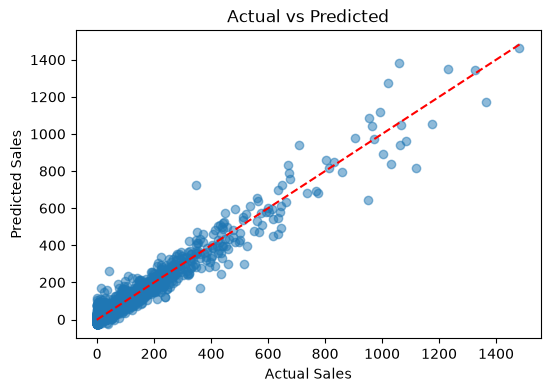

In [17]:
pred = lg.predict(X_test)

plt.figure(figsize=(6, 4))
plt.scatter(y_test, pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], "r--")

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted")
plt.show()

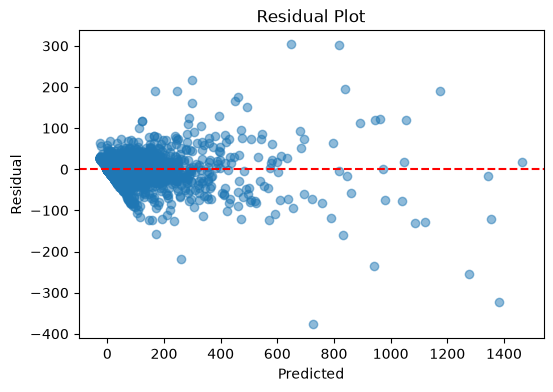

In [18]:
residual = y_test - pred

plt.figure(figsize=(6, 4))
plt.scatter(pred, residual, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

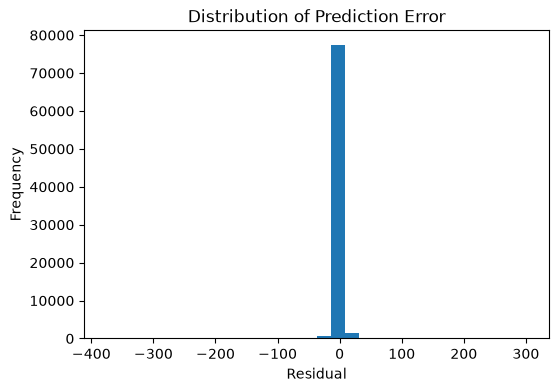

In [19]:
plt.figure(figsize=(6, 4))
plt.hist(residual, bins=30)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Error")
plt.show()

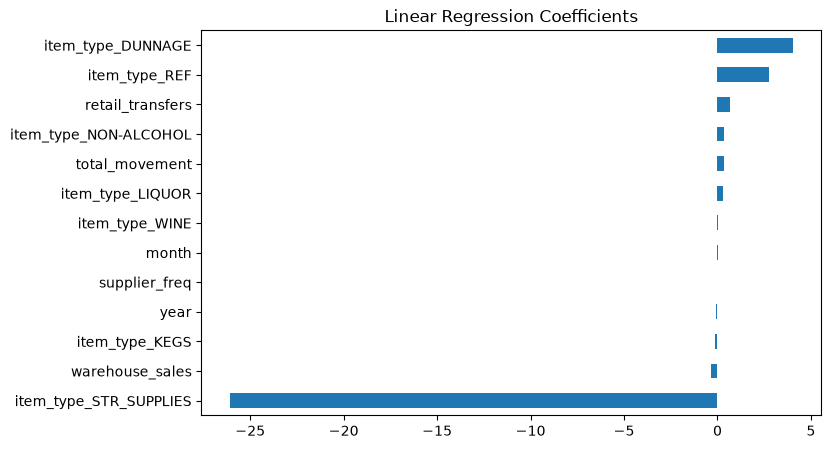

In [23]:
coef = pd.Series(
    lg.coef_,
    index=X_train.columns
)

coef.sort_values().plot.barh(figsize=(8, 5))
plt.title("Linear Regression Coefficients")
plt.show()

In [24]:
import joblib

joblib.dump(lg, "../models/linear_reg_best_model.pkl")

['../models/linear_reg_best_model.pkl']

# Conclusion

Linear Regression achieved the best overall performance while remaining simple and interpretable.

Inventory movement variables (`retail_transfers` and `total_movement`) had the greatest impact on prediction performance. Removing both features reduced model accuracy substantially, indicating that inventory movement is strongly associated with retail sales.